In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("pastel")

In [3]:
df = pd.read_csv("../data/cleaned_telco.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,True,...,False,False,False,False,False,False,False,True,False,No
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,False,...,False,False,False,False,True,False,False,False,True,No
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,False,...,False,False,False,False,False,False,False,False,True,Yes
3,1,0,0,0,0.514251,0,0,-0.746535,-0.194766,True,...,False,False,False,False,True,False,False,False,False,No
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940470,False,...,False,False,False,False,False,False,False,True,False,Yes


In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [5]:
y = y.map({"Yes": 1, "No": 0})


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
print("Train Shape: ", X_train.shape)
print("Test Shape: ", X_test.shape)

Train Shape:  (5634, 30)
Test Shape:  (1409, 30)


In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.8048261178140526

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

ROC AUC: 0.8419954015861943


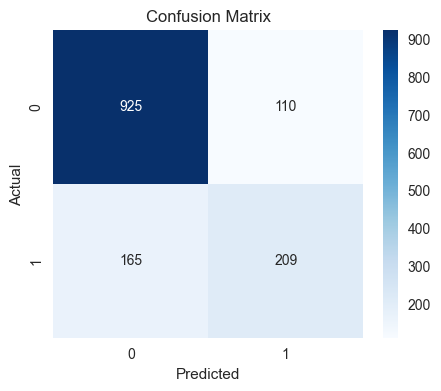

In [17]:
plt.figure(figsize = (5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()